In [15]:
%matplotlib inline
## Load tfmodisco tiling results (mech_bins) + recompute (lfc, cossim) for the 56k.
import os, sys, json, glob, h5py, numpy as np, pandas as pd, matplotlib.pyplot as plt

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap

CT  = {'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}
CTS = ['HepG2', 'K562']
N_BINS   = 10
MODE     = 'eqw'   # 'eqc' = equal-count quantiles | 'eqw' = equal-width along cossim
TAG      = f'n{N_BINS}' if MODE == 'eqc' else f'{MODE}_n{N_BINS}'
BIN_ROOT = os.path.join(REPO, 'genomic_targets/data/mech_bins')
BIN_DIR  = lambda ct, i: os.path.join(BIN_ROOT, ct, TAG, f'bin_{i:03d}')

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{c}_log2FC' for c in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')

raw = np.load(os.path.join(REPO, 'genomic_targets/data/deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n_full = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{c}_log2FC' for c in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n_full][keep]
    em.attr_hyp[ct]   = hyp
    em.attr[ct]       = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)

cossim = em.cosine_similarity(mode='importance', zscore=True)
lfc    = df['HepG2_log2FC'].values - df['K562_log2FC'].values

bins = {ct: [] for ct in CTS}
for ct in CTS:
    for d in sorted(glob.glob(os.path.join(BIN_ROOT, ct, TAG, 'bin_*'))):
        meta = json.load(open(os.path.join(d, 'meta.json')))
        idx  = np.load(os.path.join(d, 'indices.npy'))
        h5p  = os.path.join(d, 'modisco.h5')
        n_pos = n_neg = 0
        if os.path.exists(h5p):
            with h5py.File(h5p) as f:
                n_pos = len(f['pos_patterns']) if 'pos_patterns' in f else 0
                n_neg = len(f['neg_patterns']) if 'neg_patterns' in f else 0
        bins[ct].append({**meta, 'dir': d, 'indices': idx, 'n_pos': n_pos, 'n_neg': n_neg})

print(f'{len(df)} seqs    mode={MODE}  n_bins={N_BINS}    bins/ct: {[len(bins[ct]) for ct in CTS]}')

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
56975 seqs    mode=eqw  n_bins=10    bins/ct: [10, 10]


In [16]:
## print summary
def n_finemo_seqs(b):
    p = os.path.join(b['dir'], 'finemo', 'hits.tsv')
    if not os.path.exists(p): return 0
    return pd.read_csv(p, sep='\t', usecols=['peak_id'])['peak_id'].astype(int).nunique()

rows = []
for ct in CTS:
    for b in bins[ct]:
        rows.append({'ct': ct, 'bin': b['bin_idx'],
                     'n_seqs': b['n_seqs'],
                     'n_finemo_seqs': n_finemo_seqs(b),
                     'cossim_lo': b['cossim_lo'], 'cossim_hi': b['cossim_hi'],
                     'n_pos': b['n_pos'], 'n_neg': b['n_neg']})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

   ct  bin  n_seqs  n_finemo_seqs  cossim_lo  cossim_hi  n_pos  n_neg
HepG2    0      77              0  -0.848961  -0.665980      0      0
HepG2    1     184           1989  -0.662711  -0.483476      1      0
HepG2    2     338          10381  -0.479932  -0.299024      3      0
HepG2    3    1039          13567  -0.298957  -0.115696      4      0
HepG2    4    2540          21335  -0.115515   0.067555      7      0
HepG2    5    5325          31214   0.067757   0.250928     13      0
HepG2    6    9473          50005   0.250987   0.434300     15      3
HepG2    7   13762          53411   0.434328   0.617618     23      4
HepG2    8   14873          53859   0.617676   0.800922     19      6
HepG2    9    9364          45038   0.800961   0.984272     17      3
 K562    0      77              0  -0.848961  -0.665980      0      0
 K562    1     184              0  -0.662711  -0.483476      0      0
 K562    2     338           1640  -0.479932  -0.299024      0      2
 K562    3    1039  

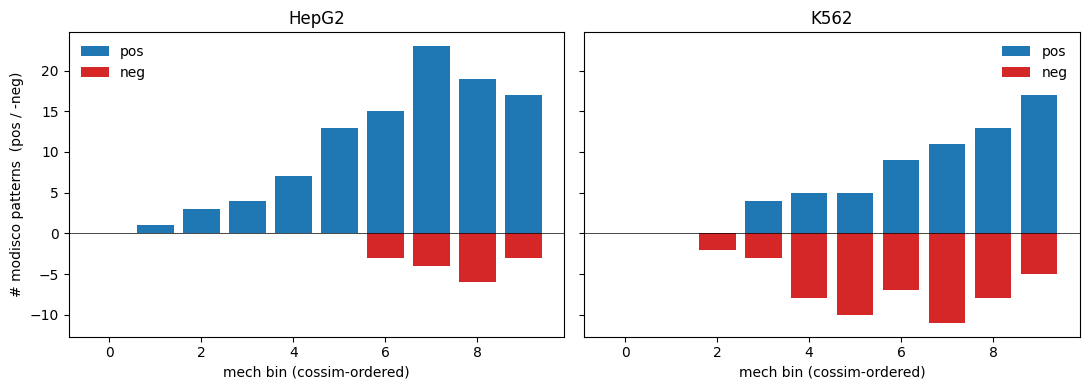

In [17]:
## visualize: # modisco patterns per bin (pos up, neg down)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, ct in zip(axes, CTS):
    xs = [b['bin_idx'] for b in bins[ct]]
    ax.bar(xs, [ b['n_pos'] for b in bins[ct]], color='#1f77b4', label='pos')
    ax.bar(xs, [-b['n_neg'] for b in bins[ct]], color='#d62728', label='neg')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('mech bin (cossim-ordered)')
    ax.set_title(ct)
    ax.legend(frameon=False)
axes[0].set_ylabel('# modisco patterns  (pos / -neg)')
plt.tight_layout(); plt.show()

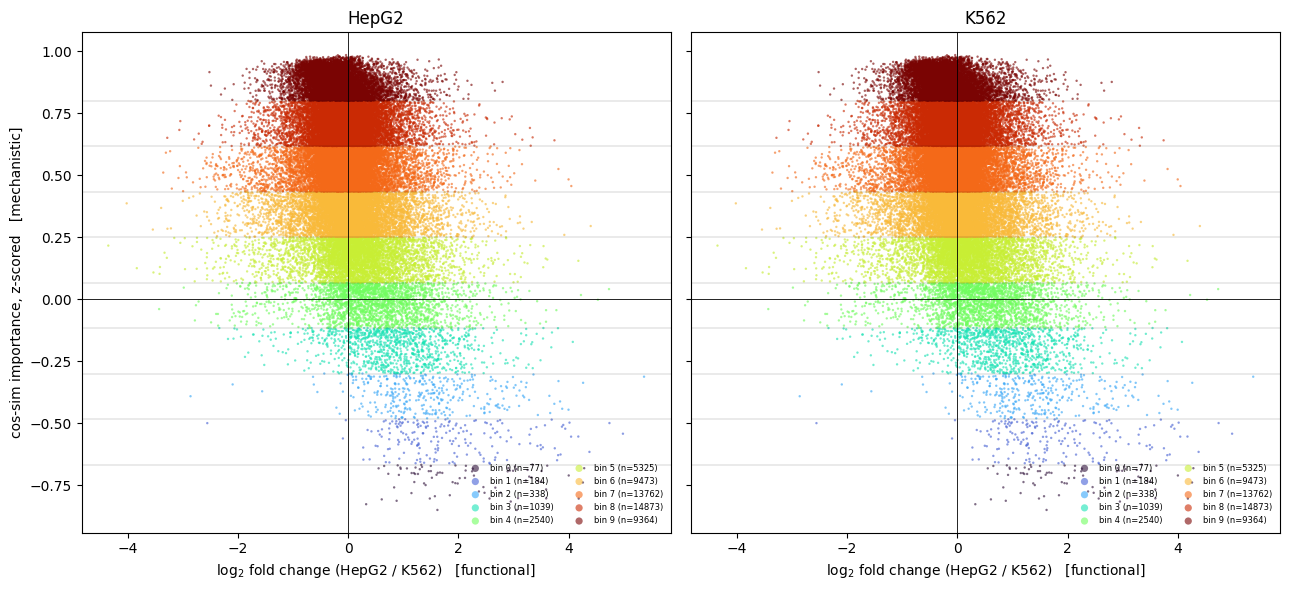

In [18]:
## show on (lfc, cossim) mech-func space; per-ct, color = bin index
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
for ax, ct in zip(axes, CTS):
    ax.scatter(lfc, cossim, s=1, c='lightgrey', alpha=0.3,
               edgecolors='none', rasterized=True)
    n_b  = len(bins[ct])
    cmap = plt.get_cmap('turbo')
    for b in bins[ct]:
        idx = b['indices']
        ax.scatter(lfc[idx], cossim[idx], s=3, alpha=0.6, edgecolors='none',
                   color=cmap(b['bin_idx'] / max(1, n_b - 1)),
                   label=f"bin {b['bin_idx']} (n={b['n_seqs']})", rasterized=True)
    edges = sorted({b['cossim_hi'] for b in bins[ct]})[:-1]
    for e in edges:
        ax.axhline(e, color='k', lw=0.3, alpha=0.4)
    ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
    ax.set_xlabel('log$_2$ fold change (HepG2 / K562)   [functional]')
    ax.set_title(ct)
    ax.legend(frameon=False, fontsize=6, loc='lower right',
              markerscale=3, ncol=2)
axes[0].set_ylabel('cos-sim importance, z-scored   [mechanistic]')
plt.tight_layout(); plt.show()


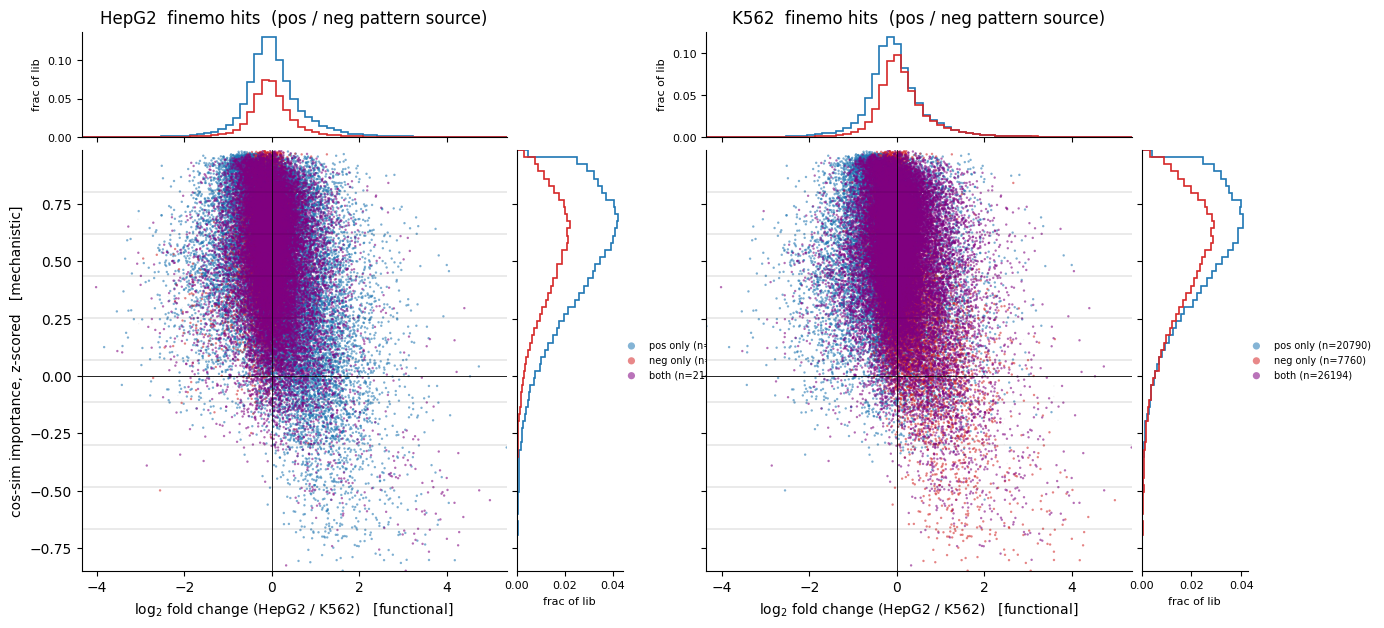

In [25]:
## finemo hits on (lfc, cossim), per-ct, colored by pos/neg pattern source (blue=pos, red=neg).
n   = len(df)
fin = np.isfinite(lfc) & np.isfinite(cossim)
x_lim = (np.nanmin(lfc[fin]),    np.nanmax(lfc[fin]))
y_lim = (np.nanmin(cossim[fin]), np.nanmax(cossim[fin]))
x_bins_h = np.linspace(*x_lim, 60); y_bins_h = np.linspace(*y_lim, 60)

def hits_pos_neg_masks(b, n):
    p = os.path.join(b['dir'], 'finemo', 'hits.tsv')
    pos = np.zeros(n, dtype=bool); neg = np.zeros(n, dtype=bool)
    if not os.path.exists(p):
        return pos, neg
    h = pd.read_csv(p, sep='\t', usecols=['peak_id', 'motif_name'])
    h['peak_id'] = h['peak_id'].astype(int)
    h = h[h['peak_id'] < n]
    p_ids = h.loc[h['motif_name'].str.startswith('pos_'), 'peak_id'].unique()
    n_ids = h.loc[h['motif_name'].str.startswith('neg_'), 'peak_id'].unique()
    pos[p_ids] = True; neg[n_ids] = True
    return pos, neg

C_POS, C_NEG = '#1f77b4', '#d62728'

fig = plt.figure(figsize=(16, 7))
gs  = fig.add_gridspec(2, 6,
                       width_ratios=[4, 1, 0.6, 4, 1, 0.6],
                       height_ratios=[1, 4],
                       hspace=0.05, wspace=0.05)

scatter_axes = []
for col, ct in zip([0, 3], CTS):
    ax_main = fig.add_subplot(gs[1, col])
    ax_top  = fig.add_subplot(gs[0, col],     sharex=ax_main)
    ax_rt   = fig.add_subplot(gs[1, col + 1], sharey=ax_main)

    ax_main.scatter(lfc[fin], cossim[fin], s=1, c='lightgrey', alpha=0.3,
                    edgecolors='none', rasterized=True)

    pos_any = np.zeros(n, dtype=bool)
    neg_any = np.zeros(n, dtype=bool)
    for b in bins[ct]:
        pm, nm = hits_pos_neg_masks(b, n)
        pos_any |= pm; neg_any |= nm

    pos_only = pos_any & ~neg_any & fin
    neg_only = neg_any & ~pos_any & fin
    both     = pos_any & neg_any & fin

    ax_main.scatter(lfc[pos_only], cossim[pos_only], s=3, color=C_POS, alpha=0.55,
                    edgecolors='none', rasterized=True, label=f'pos only (n={pos_only.sum()})')
    ax_main.scatter(lfc[neg_only], cossim[neg_only], s=3, color=C_NEG, alpha=0.55,
                    edgecolors='none', rasterized=True, label=f'neg only (n={neg_only.sum()})')
    ax_main.scatter(lfc[both],     cossim[both],     s=3, color='purple', alpha=0.55,
                    edgecolors='none', rasterized=True, label=f'both (n={both.sum()})')

    for m, c in [(pos_any & fin, C_POS), (neg_any & fin, C_NEG)]:
        if m.sum() < 2: continue
        w = np.full(m.sum(), 1.0 / n)
        ax_top.hist(lfc[m],   bins=x_bins_h, color=c, weights=w,
                    histtype='step', linewidth=1.2)
        ax_rt.hist(cossim[m], bins=y_bins_h, color=c, weights=w,
                   histtype='step', linewidth=1.2, orientation='horizontal')

    edges = sorted({b['cossim_hi'] for b in bins[ct]})[:-1]
    for e in edges:
        ax_main.axhline(e, color='k', lw=0.3, alpha=0.4)
    ax_main.axhline(0, color='k', lw=0.6); ax_main.axvline(0, color='k', lw=0.6)
    ax_main.set_xlim(x_lim); ax_main.set_ylim(y_lim)
    ax_main.set_xlabel('log$_2$ fold change (HepG2 / K562)   [functional]')
    ax_main.legend(frameon=False, fontsize=7,
                   loc='center left', bbox_to_anchor=(1.25, 0.5),
                   markerscale=3, ncol=1)
    for sp in ('top', 'right'): ax_main.spines[sp].set_visible(False)

    ax_top.set_title(f'{ct}  finemo hits  (pos / neg pattern source)')
    ax_top.set_ylabel('frac of lib', fontsize=8)
    ax_rt.set_xlabel('frac of lib', fontsize=8)
    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_rt.get_yticklabels(),  visible=False)
    ax_top.tick_params(axis='y', labelsize=8)
    ax_rt.tick_params(axis='x',  labelsize=8)
    for sp in ('top', 'right'):
        ax_top.spines[sp].set_visible(False); ax_rt.spines[sp].set_visible(False)

    scatter_axes.append(ax_main)

scatter_axes[0].set_ylabel('cos-sim importance, z-scored   [mechanistic]')
plt.setp(scatter_axes[1].get_yticklabels(), visible=False)
plt.show()

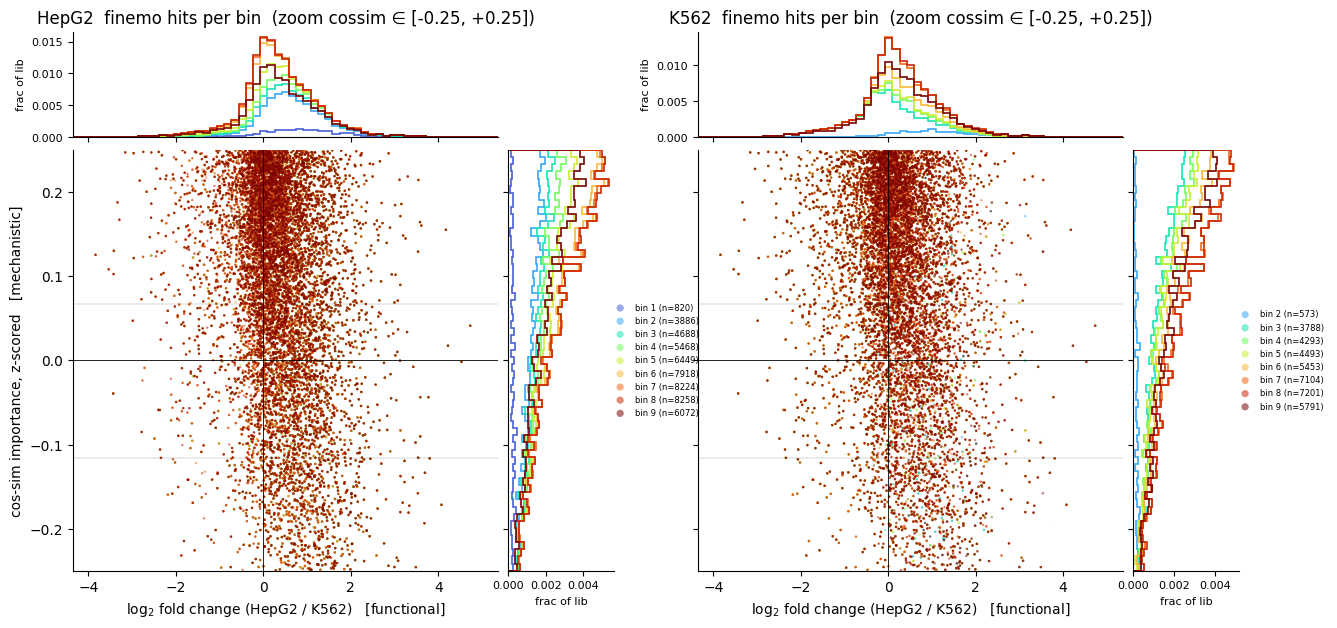

In [26]:
## zoom: same as "finemo hits per bin" plot, but ylim cossim ∈ [-0.25, +0.25]
ZLO, ZHI = -0.25, 0.25
n   = len(df)
fin = np.isfinite(lfc) & np.isfinite(cossim)
x_lim = (np.nanmin(lfc[fin]),    np.nanmax(lfc[fin]))
y_lim = (ZLO, ZHI)
x_bins_h = np.linspace(*x_lim, 60); y_bins_h = np.linspace(*y_lim, 60)

fig = plt.figure(figsize=(16, 7))
gs  = fig.add_gridspec(2, 6,
                       width_ratios=[4, 1, 0.6, 4, 1, 0.6],
                       height_ratios=[1, 4],
                       hspace=0.05, wspace=0.05)

scatter_axes = []
for col, ct in zip([0, 3], CTS):
    ax_main = fig.add_subplot(gs[1, col])
    ax_top  = fig.add_subplot(gs[0, col],     sharex=ax_main)
    ax_rt   = fig.add_subplot(gs[1, col + 1], sharey=ax_main)

    ax_main.scatter(lfc[fin], cossim[fin], s=1, c='lightgrey', alpha=0.3,
                    edgecolors='none', rasterized=True)

    n_b  = len(bins[ct])
    cmap = plt.get_cmap('turbo')
    for b in bins[ct]:
        m = bin_hits_mask(b, n) & fin & (cossim >= ZLO) & (cossim <= ZHI)
        if m.sum() < 2: continue
        c = cmap(b['bin_idx'] / max(1, n_b - 1))
        ax_main.scatter(lfc[m], cossim[m], s=3, color=c, alpha=0.55,
                        edgecolors='none', rasterized=True,
                        label=f"bin {b['bin_idx']} (n={m.sum()})")
        w = np.full(m.sum(), 1.0 / n)
        ax_top.hist(lfc[m],   bins=x_bins_h, color=c, weights=w,
                    histtype='step', linewidth=1.2)
        ax_rt.hist(cossim[m], bins=y_bins_h, color=c, weights=w,
                   histtype='step', linewidth=1.2, orientation='horizontal')

    edges = sorted({b['cossim_hi'] for b in bins[ct]})[:-1]
    for e in edges:
        ax_main.axhline(e, color='k', lw=0.3, alpha=0.4)
    ax_main.axhline(0, color='k', lw=0.6); ax_main.axvline(0, color='k', lw=0.6)
    ax_main.set_xlim(x_lim); ax_main.set_ylim(y_lim)
    ax_main.set_xlabel('log$_2$ fold change (HepG2 / K562)   [functional]')
    ax_main.legend(frameon=False, fontsize=6,
                   loc='center left', bbox_to_anchor=(1.25, 0.5),
                   markerscale=3, ncol=1)
    for sp in ('top', 'right'): ax_main.spines[sp].set_visible(False)

    ax_top.set_title(f'{ct}  finemo hits per bin  (zoom cossim ∈ [{ZLO:+.2f}, {ZHI:+.2f}])')
    ax_top.set_ylabel('frac of lib', fontsize=8)
    ax_rt.set_xlabel('frac of lib', fontsize=8)
    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_rt.get_yticklabels(),  visible=False)
    ax_top.tick_params(axis='y', labelsize=8)
    ax_rt.tick_params(axis='x',  labelsize=8)
    for sp in ('top', 'right'):
        ax_top.spines[sp].set_visible(False); ax_rt.spines[sp].set_visible(False)

    scatter_axes.append(ax_main)

scatter_axes[0].set_ylabel('cos-sim importance, z-scored   [mechanistic]')
plt.setp(scatter_axes[1].get_yticklabels(), visible=False)
plt.show()

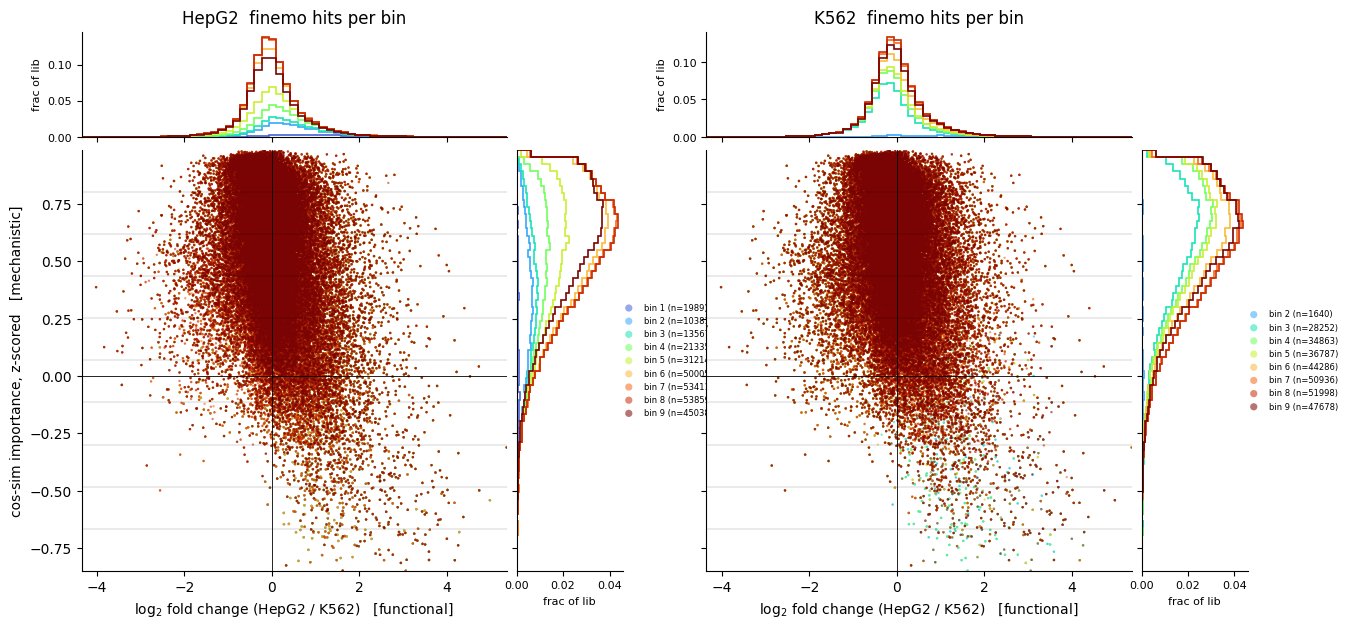

In [22]:
## finemo hits (per bin) on (lfc, cossim), per-ct, with marginal density distributions
n   = len(df)
fin = np.isfinite(lfc) & np.isfinite(cossim)
x_lim = (np.nanmin(lfc[fin]),    np.nanmax(lfc[fin]))
y_lim = (np.nanmin(cossim[fin]), np.nanmax(cossim[fin]))
x_bins_h = np.linspace(*x_lim, 60); y_bins_h = np.linspace(*y_lim, 60)

def bin_hits_mask(b, n):
    p = os.path.join(b['dir'], 'finemo', 'hits.tsv')
    if not os.path.exists(p):
        return np.zeros(n, dtype=bool)
    ids = pd.read_csv(p, sep='\t', usecols=['peak_id'])['peak_id'].astype(int).unique()
    ids = ids[ids < n]
    m = np.zeros(n, dtype=bool); m[ids] = True
    return m

fig = plt.figure(figsize=(16, 7))
gs  = fig.add_gridspec(2, 6,
                       width_ratios=[4, 1, 0.6, 4, 1, 0.6],
                       height_ratios=[1, 4],
                       hspace=0.05, wspace=0.05)

scatter_axes = []
for col, ct in zip([0, 3], CTS):
    ax_main = fig.add_subplot(gs[1, col])
    ax_top  = fig.add_subplot(gs[0, col],     sharex=ax_main)
    ax_rt   = fig.add_subplot(gs[1, col + 1], sharey=ax_main)

    ax_main.scatter(lfc[fin], cossim[fin], s=1, c='lightgrey', alpha=0.3,
                    edgecolors='none', rasterized=True)

    n_b  = len(bins[ct])
    cmap = plt.get_cmap('turbo')
    for b in bins[ct]:
        m = bin_hits_mask(b, n) & fin
        if m.sum() < 2: continue
        c = cmap(b['bin_idx'] / max(1, n_b - 1))
        ax_main.scatter(lfc[m], cossim[m], s=3, color=c, alpha=0.55,
                        edgecolors='none', rasterized=True,
                        label=f"bin {b['bin_idx']} (n={m.sum()})")
        w = np.full(m.sum(), 1.0 / n)
        ax_top.hist(lfc[m],   bins=x_bins_h, color=c, weights=w,
                    histtype='step', linewidth=1.2)
        ax_rt.hist(cossim[m], bins=y_bins_h, color=c, weights=w,
                   histtype='step', linewidth=1.2, orientation='horizontal')

    edges = sorted({b['cossim_hi'] for b in bins[ct]})[:-1]
    for e in edges:
        ax_main.axhline(e, color='k', lw=0.3, alpha=0.4)
    ax_main.axhline(0, color='k', lw=0.6); ax_main.axvline(0, color='k', lw=0.6)
    ax_main.set_xlim(x_lim); ax_main.set_ylim(y_lim)
    ax_main.set_xlabel('log$_2$ fold change (HepG2 / K562)   [functional]')
    ax_main.legend(frameon=False, fontsize=6,
                   loc='center left', bbox_to_anchor=(1.25, 0.5),
                   markerscale=3, ncol=1)
    for sp in ('top', 'right'): ax_main.spines[sp].set_visible(False)

    ax_top.set_title(f'{ct}  finemo hits per bin')
    ax_top.set_ylabel('frac of lib', fontsize=8)
    ax_rt.set_xlabel('frac of lib', fontsize=8)
    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_rt.get_yticklabels(),  visible=False)
    ax_top.tick_params(axis='y', labelsize=8)
    ax_rt.tick_params(axis='x',  labelsize=8)
    for sp in ('top', 'right'):
        ax_top.spines[sp].set_visible(False); ax_rt.spines[sp].set_visible(False)

    scatter_axes.append(ax_main)

scatter_axes[0].set_ylabel('cos-sim importance, z-scored   [mechanistic]')
plt.setp(scatter_axes[1].get_yticklabels(), visible=False)
plt.show()


  HepG2  bin 1: 0 CTCF matches
  HepG2  bin 9: 1 CTCF matches
  K562  bin 1: 0 CTCF matches
  K562  bin 9: 2 CTCF matches


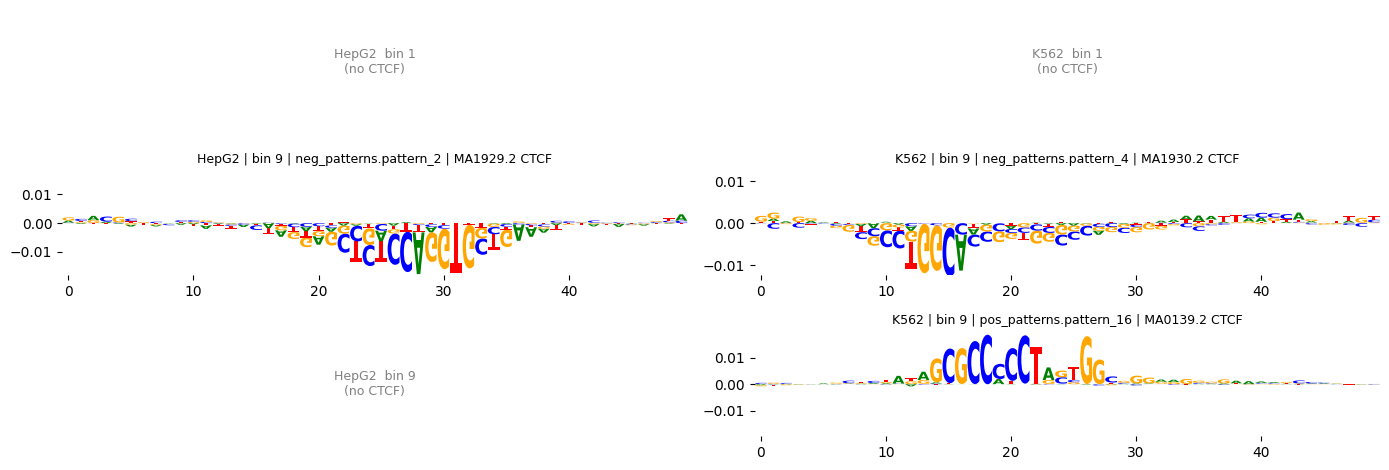

In [24]:
## Run/cache TOMTOM (JASPAR2026) per bin and plot CTCF CWMs for the cossim extremes (bin 0, last bin).
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering as es
es._load_heavy_deps()
fast_logo = es.fast_logo
JASPAR_MEME = es.JASPAR_MEME
from modiscolite import report as mr

EXTREMES = [1, len(bins[CTS[0]]) - 1]   # most cossim≈-1, most cossim≈+1

def ensure_tomtom(bin_dir):
    out = os.path.join(bin_dir, 'tomtom_jaspar2026.json')
    if os.path.exists(out):
        return json.load(open(out))
    h5 = os.path.join(bin_dir, 'modisco.h5')
    ann = {}
    for grp in ('pos_patterns', 'neg_patterns'):
        with h5py.File(h5) as f:
            if grp not in f: continue
        d = mr.tomtomlite_dataframe(modisco_h5py=h5, output_dir=bin_dir,
                                    meme_motif_db=JASPAR_MEME,
                                    pattern_groups=[grp], top_n_matches=1)
        if 'match0' in d:
            for k, v in d['match0'].items():
                ann[f'{grp}.pattern_{int(k)}'] = str(v)
    json.dump(ann, open(out, 'w'), indent=2, sort_keys=True)
    print(f'  wrote {out}  ({len(ann)} patterns)')
    return ann

def cwm_for(h5, key):
    grp, pat = key.split('.')
    i = int(pat.split('_')[-1])
    with h5py.File(h5) as f:
        return f[grp][f'pattern_{i}']['contrib_scores'][...]

# per (ct, bin) -> list of (key, ann, cwm) for CTCF matches
ctcf = {(ct, bi): [] for ct in CTS for bi in EXTREMES}
for (ct, bi) in ctcf:
    b   = next(x for x in bins[ct] if x['bin_idx'] == bi)
    ann = ensure_tomtom(b['dir'])
    for key, a in ann.items():
        if 'CTCF' in a.upper():
            ctcf[(ct, bi)].append((key, a, cwm_for(os.path.join(b['dir'], 'modisco.h5'), key)))

print()
for (ct, bi), hits in ctcf.items():
    print(f'  {ct}  bin {bi}: {len(hits)} CTCF matches')

# Always show both cts side-by-side. Rows per bin = max CTCF count across cts (>=1).
n_rows_per_bin = {bi: max(max(len(ctcf[(ct, bi)]) for ct in CTS), 1) for bi in EXTREMES}
total_rows = sum(n_rows_per_bin.values())
fig, axes = plt.subplots(total_rows, len(CTS),
                         figsize=(7 * len(CTS), 1.6 * total_rows),
                         squeeze=False)

row = 0
for bi in EXTREMES:
    nr = n_rows_per_bin[bi]
    for ci, ct in enumerate(CTS):
        hits = ctcf[(ct, bi)]
        for r_off in range(nr):
            ax = axes[row + r_off, ci]
            if r_off < len(hits):
                key, a, cwm = hits[r_off]
                yabs = max(abs(cwm).max() * 1.05, 1e-6)
                fast_logo(cwm.T, ax=ax, ylim=(-yabs, yabs))
                ax.set_title(f'{ct} | bin {bi} | {key} | {a}', fontsize=9)
            else:
                ax.text(0.5, 0.5, f'{ct}  bin {bi}\n(no CTCF)',
                        ha='center', va='center', fontsize=9, color='grey',
                        transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values(): sp.set_visible(False)
    row += nr

plt.tight_layout(); plt.show()

   ct  bin  n_seqs  n_hits  n_hit_seqs  hits_per_seq  frac_hit
HepG2    0      77       0           0      0.000000  0.000000
HepG2    1     184    2798        1989     15.206522 10.809783
HepG2    2     338   12857       10381     38.038462 30.713018
HepG2    3    1039   17547       13567     16.888354 13.057748
HepG2    4    2540   33711       21335     13.272047  8.399606
HepG2    5    5325   58667       31214     11.017277  5.861784
HepG2    6    9473  133195       50005     14.060488  5.278687
HepG2    7   13762  160134       53411     11.635954  3.881049
HepG2    8   14873  165555       53859     11.131245  3.621260
HepG2    9    9364  102291       45038     10.923857  4.809697
 K562    0      77       0           0      0.000000  0.000000
 K562    1     184       0           0      0.000000  0.000000
 K562    2     338    2252        1640      6.662722  4.852071
 K562    3    1039   38974       28252     37.511068 27.191530
 K562    4    2540   53868       34863     21.207874 13

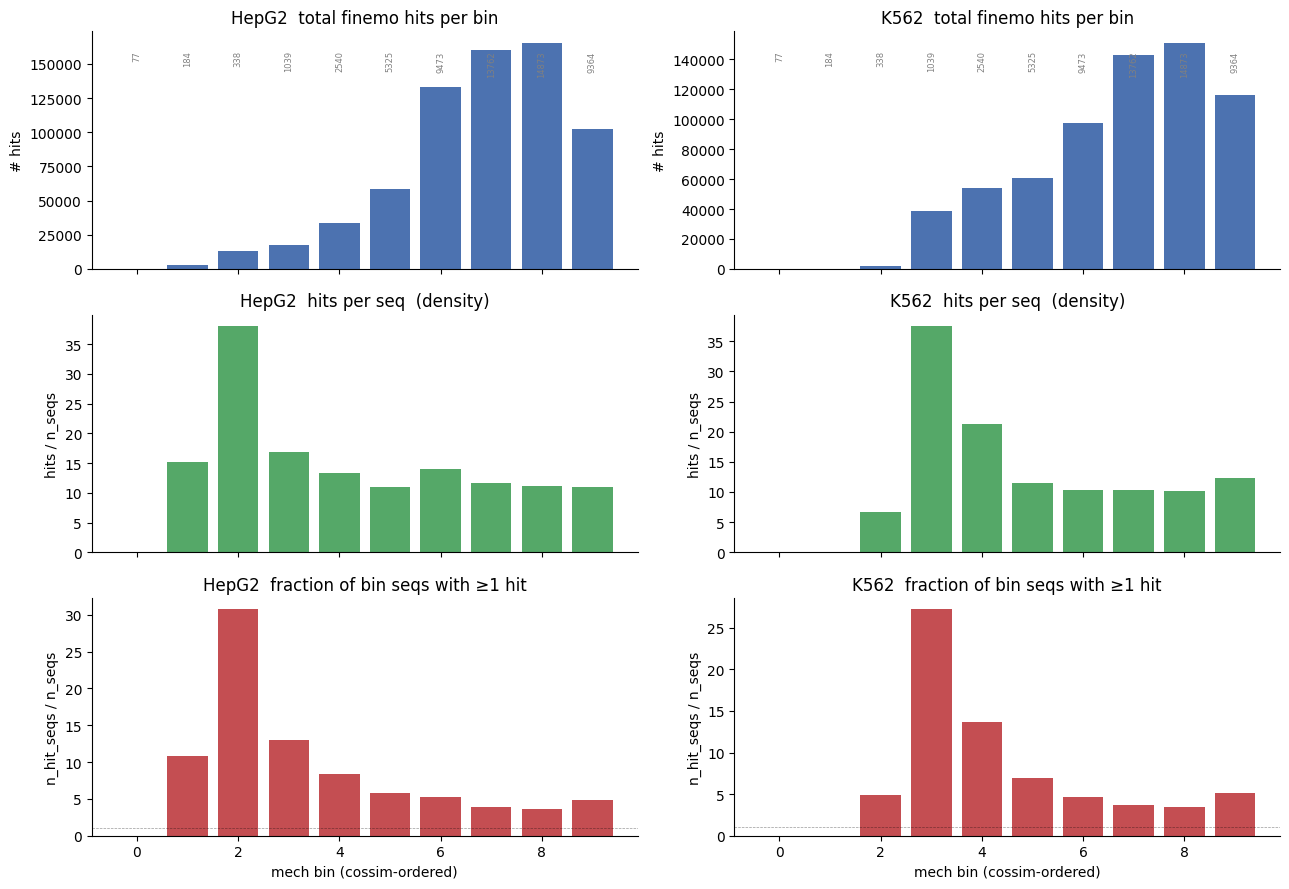

In [31]:
## per-bin finemo hit coverage — can a tiny bin (e.g. bin 0/1) describe the whole mech axis?
def hit_stats(b):
    p = os.path.join(b['dir'], 'finemo', 'hits.tsv')
    if not os.path.exists(p):
        return 0, 0
    h = pd.read_csv(p, sep='\t', usecols=['peak_id'])
    return len(h), h['peak_id'].astype(int).nunique()

cov_rows = []
for ct in CTS:
    for b in bins[ct]:
        n_hits, n_hit_seqs = hit_stats(b)
        cov_rows.append({'ct': ct, 'bin': b['bin_idx'], 'n_seqs': b['n_seqs'],
                         'n_hits': n_hits, 'n_hit_seqs': n_hit_seqs,
                         'hits_per_seq': n_hits / max(b['n_seqs'], 1),
                         'frac_hit': n_hit_seqs / max(b['n_seqs'], 1)})
cov = pd.DataFrame(cov_rows)
print(cov.to_string(index=False))

fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)
for ci, ct in enumerate(CTS):
    sub = cov[cov['ct'] == ct]
    ax0, ax1, ax2 = axes[0, ci], axes[1, ci], axes[2, ci]

    ax0.bar(sub['bin'], sub['n_hits'], color='#4c72b0')
    ax0.set_title(f'{ct}  total finemo hits per bin')
    ax0.set_ylabel('# hits')

    ax1.bar(sub['bin'], sub['hits_per_seq'], color='#55a868')
    ax1.set_title(f'{ct}  hits per seq  (density)')
    ax1.set_ylabel('hits / n_seqs')

    ax2.bar(sub['bin'], sub['frac_hit'], color='#c44e52')
    ax2.axhline(1, color='k', lw=0.5, ls='--', alpha=0.4)
    ax2.set_title(f'{ct}  fraction of bin seqs with ≥1 hit')
    ax2.set_ylabel('n_hit_seqs / n_seqs')
    ax2.set_xlabel('mech bin (cossim-ordered)')

    # annotate n_seqs on top axis to flag small bins
    for x, n_s in zip(sub['bin'], sub['n_seqs']):
        ax0.text(x, ax0.get_ylim()[1] * 0.92, f'{n_s}',
                 ha='center', va='top', fontsize=6, color='grey', rotation=90)

for ax in axes.flat:
    for sp in ('top', 'right'): ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

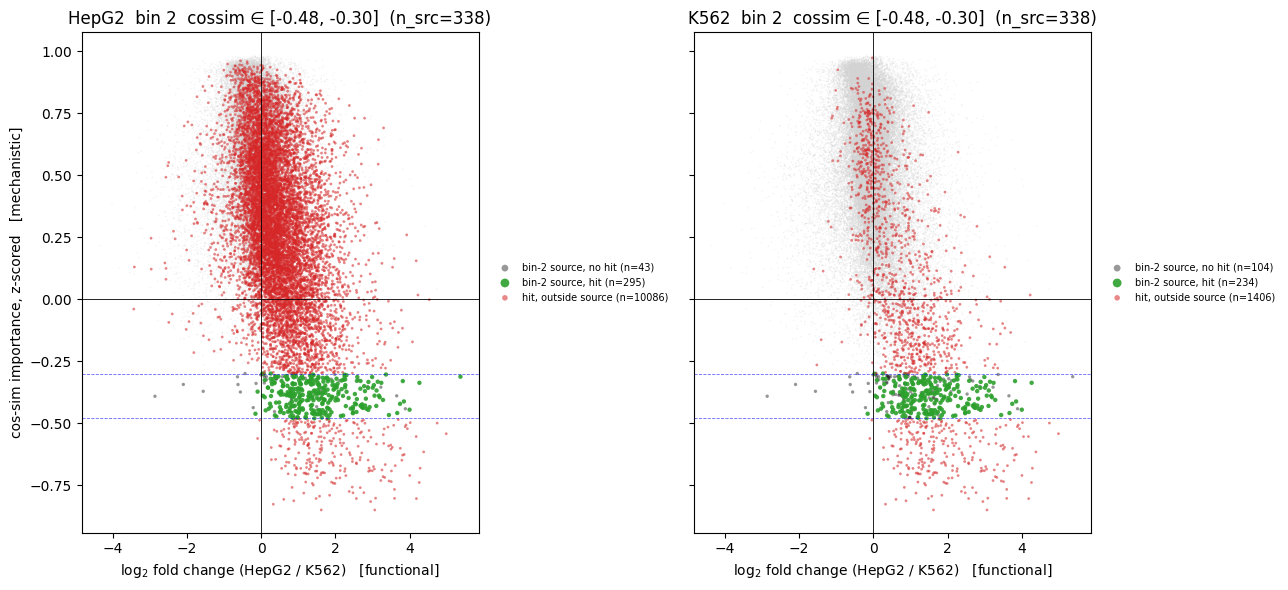

In [28]:
## bin-2 only: where in (lfc, cossim) space do bin-2's finemo hits land (full-library scan)?
TARGET_BIN = 2

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
for ax, ct in zip(axes, CTS):
    ax.scatter(lfc[fin], cossim[fin], s=1, c='lightgrey', alpha=0.3,
               edgecolors='none', rasterized=True)

    b = next(x for x in bins[ct] if x['bin_idx'] == TARGET_BIN)
    src = np.zeros(len(df), dtype=bool); src[b['indices']] = True
    hit = bin_hits_mask(b, len(df))

    src_only = src & ~hit & fin
    hit_in_src  = src & hit & fin
    hit_outside = ~src & hit & fin

    ax.scatter(lfc[src_only],   cossim[src_only],   s=6, color='k',        alpha=0.4,
               edgecolors='none', rasterized=True,
               label=f'bin-{TARGET_BIN} source, no hit (n={src_only.sum()})')
    ax.scatter(lfc[hit_in_src], cossim[hit_in_src], s=10, color='#2ca02c', alpha=0.9,
               edgecolors='none', rasterized=True,
               label=f'bin-{TARGET_BIN} source, hit (n={hit_in_src.sum()})')
    ax.scatter(lfc[hit_outside],cossim[hit_outside],s=4, color='#d62728',  alpha=0.55,
               edgecolors='none', rasterized=True,
               label=f'hit, outside source (n={hit_outside.sum()})')

    ax.axhline(b['cossim_lo'], color='b', lw=0.6, ls='--', alpha=0.6)
    ax.axhline(b['cossim_hi'], color='b', lw=0.6, ls='--', alpha=0.6)
    ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
    ax.set_xlabel('log$_2$ fold change (HepG2 / K562)   [functional]')
    ax.set_title(f'{ct}  bin {TARGET_BIN}  '
                 f'cossim ∈ [{b["cossim_lo"]:+.2f}, {b["cossim_hi"]:+.2f}]  '
                 f'(n_src={b["n_seqs"]})')
    ax.legend(frameon=False, fontsize=7,
              loc='center left', bbox_to_anchor=(1.02, 0.5), markerscale=2)
axes[0].set_ylabel('cos-sim importance, z-scored   [mechanistic]')
plt.tight_layout(); plt.show()